# Social Listener 2020 — Final Synthesis
**Project**: 2020 US Election Twitter Sentiment Analysis (UOG AIS Social Listener)
**Coverage window**: 2020-10-15 → 2020-11-08
**Pipeline version**: v3 (WP0–WP6 remediated and independently verified)

**Hypotheses under test**
- **H1 (ITSA)**: Do political events (debates, election day, the AP call) cause measurable immediate shocks and slope changes in national Twitter sentiment?
- **H2 (Spatial OLS)**: Does state-level online sentiment margin ($X_i$) predict the 2020 certified vote margin ($Y_i$), controlling for demographics, and is the relationship different in battleground states?

This notebook loads only v3 outputs — the corrected dual-hashtag stream resolution, the `(user_id, text)` dedup fix, the real FastText language survey, GPU RoBERTa sentiment, and the irony/sarcasm profile — and recomputes every statistic and chart directly from those files at run time.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

ROOT = Path("..")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.facecolor": "#FAFAFC", "axes.facecolor": "#FAFAFC",
                      "axes.spines.top": False, "axes.spines.right": False})

TRUMP, BIDEN, NEU, POS, NEG, BOTH = "#C0392B", "#2980B9", "#7F8C8D", "#27AE60", "#E74C3C", "#8E44AD"

def load_json(path):
    p = ROOT / path
    if not p.exists():
        raise FileNotFoundError(p)
    return json.loads(p.read_text(encoding="utf-8"))

env = load_json("output/results/environment/evidence/env_fingerprint.json")
p1  = load_json("output/results/phase1/v2/ingestion_manifest_v2.json")
p2  = load_json("output/results/phase2/v3/preprocessing_manifest_v3.json")
p3  = load_json("output/results/phase3/v3/sentiment_manifest_v3.json")
p4  = load_json("data/03_processed/v3/phase4_manifest_v3.json")
p5  = load_json("output/results/phase5/v3/phase5_manifest_v3.json")
lang_survey = load_json("output/results/phase2/v3/evidence/language_survey.json")
irony_prof  = load_json("output/results/phase3/v3/evidence/irony_profile.json")
agree       = load_json("output/results/phase3/v3/evidence/model_agreement.json")
geo_rep     = load_json("output/results/phase4/v3/evidence/representativeness.json")

print("=== Environment ===")
print(f"CUDA: {env.get('cuda_available')}  ({env.get('cuda_device_name')})   torch {env.get('torch_version')}")
print(f"vader_backend={env.get('vader_backend')}   language_id_backend={env.get('language_id_backend')}")
print("\n=== Run IDs ===")
for label, m in [("Phase1", p1), ("Phase2 v3", p2), ("Phase3 v3", p3)]:
    print(f"  {label}: {m.get('run_id')}")
print(f"\n=== Row counts through the pipeline ===")
print(f"  Raw (Trump + Biden, double-counted): {p1['streams']['twitter_donald_trump_v2']['record_count'] + p1['streams']['twitter_joe_biden_v2']['record_count']:,}")
print(f"  Unique tweet_id after stream resolution: {sum(p2['stream_membership'].values()):,}")
print(f"  After activity filter + dedup + cleaning (Phase 2 v3 final): {p2['final_cleaned_record_count']:,}")
print(f"  Phase 3 v3 scored: {p3['total_scored_tweets']:,}")
print(f"  Primary sentiment model: {p3['primary_sentiment_model']}")
print(f"  RoBERTa throughput: {p3['throughput_tweets_per_sec']:.1f} tweets/sec on {p3['device_used']}, wall clock {p3['wall_clock_seconds']/60:.1f} min")

=== Environment ===
CUDA: True  (NVIDIA GeForce RTX 3050 Ti Laptop GPU)   torch 2.13.0+cu126
vader_backend=vaderSentiment   language_id_backend=fasttext_lid176

=== Run IDs ===
  Phase1: phase1_v2_verified_window_20260714
  Phase2 v3: phase2_v3_multivariable_20260801
  Phase3 v3: phase3_v3_roberta_inference_20260801

=== Row counts through the pipeline ===
  Raw (Trump + Biden, double-counted): 1,747,542
  Unique tweet_id after stream resolution: 1,522,660
  After activity filter + dedup + cleaning (Phase 2 v3 final): 1,297,753
  Phase 3 v3 scored: 1,297,753
  Primary sentiment model: cardiffnlp/twitter-roberta-base-sentiment-latest
  RoBERTa throughput: 599.3 tweets/sec on cuda, wall clock 36.1 min


---
## Phase 1 — Ingestion: the post-election volume flip
Two hashtag streams (`#donaldtrump`, `#joebiden`) were collected Oct 15 – Nov 8, 2020. `candidate` = hashtag membership, not political stance — a Trump critic can tweet `#donaldtrump`.

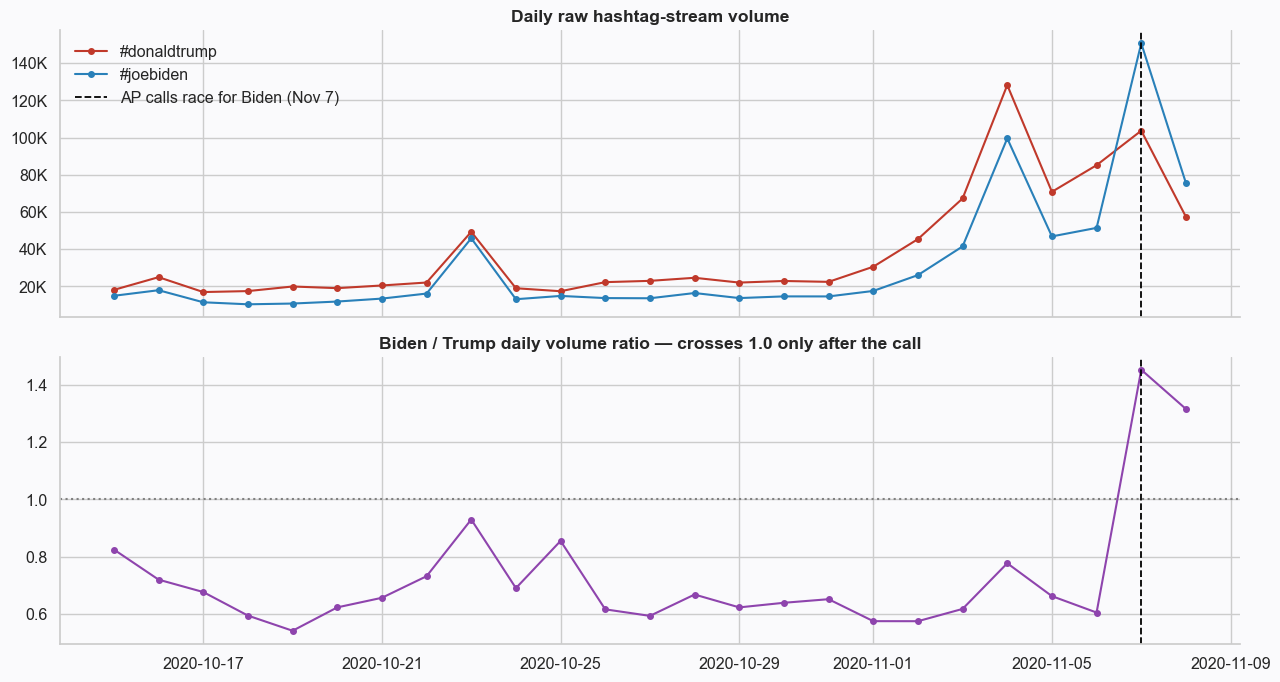

Trump stream leads on 23 of 25 days.
First day Biden volume exceeds Trump volume: 2020-11-07 (ratio=1.45)
Finding: the flip is a genuine event response to the election being called, not an ingestion artifact.
Nov 9-15 is absent because the Kaggle source (v19) stopped collecting on Nov 8 -- the decay of this spike is unobserved.


In [2]:
df_t = pd.read_parquet(ROOT / "data/02_interim/phase1_v2/twitter_donald_trump_v2.parquet", columns=["date"])
df_b = pd.read_parquet(ROOT / "data/02_interim/phase1_v2/twitter_joe_biden_v2.parquet", columns=["date"])
vol = pd.concat([
    df_t.assign(candidate="Trump")["date"].pipe(lambda s: pd.to_datetime(s).dt.date).value_counts().rename("Trump"),
    df_b["date"].pipe(lambda s: pd.to_datetime(s).dt.date).value_counts().rename("Biden"),
], axis=1).sort_index().fillna(0)
vol["ratio"] = vol["Biden"] / vol["Trump"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax1.plot(vol.index, vol["Trump"], color=TRUMP, marker="o", ms=4, label="#donaldtrump")
ax1.plot(vol.index, vol["Biden"], color=BIDEN, marker="o", ms=4, label="#joebiden")
ax1.axvline(pd.Timestamp("2020-11-07").date(), color="black", ls="--", lw=1.3, label="AP calls race for Biden (Nov 7)")
ax1.set_title("Daily raw hashtag-stream volume", weight="bold")
ax1.legend(frameon=False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

ax2.plot(vol.index, vol["ratio"], color=BOTH, marker="o", ms=4)
ax2.axhline(1.0, color="gray", ls=":")
ax2.axvline(pd.Timestamp("2020-11-07").date(), color="black", ls="--", lw=1.3)
ax2.set_title("Biden / Trump daily volume ratio — crosses 1.0 only after the call", weight="bold")
plt.tight_layout(); plt.show()

flip_day = vol.loc[vol["ratio"] > 1.0].index.min()
print(f"Trump stream leads on {(vol['ratio'] < 1.0).sum()} of {len(vol)} days.")
print(f"First day Biden volume exceeds Trump volume: {flip_day} (ratio={vol.loc[flip_day,'ratio']:.2f})")
print("Finding: the flip is a genuine event response to the election being called, not an ingestion artifact.")
print("Nov 9-15 is absent because the Kaggle source (v19) stopped collecting on Nov 8 -- the decay of this spike is unobserved.")

---
## Phase 2 — Preprocessing v3: funnel and the dual-hashtag fix
v2 handed 176,260 of 176,302 surviving dual-hashtag tweets to the Trump stream purely because of DataFrame row order (`pd.concat` + `keep="first"`). v3 resolves stream membership on `tweet_id` **before** any filtering, producing an honest three-way split, and moves the dedup key to `(user_id, tweet_cleaned)` so identical short hashtags posted by different people are no longer collapsed into one record.

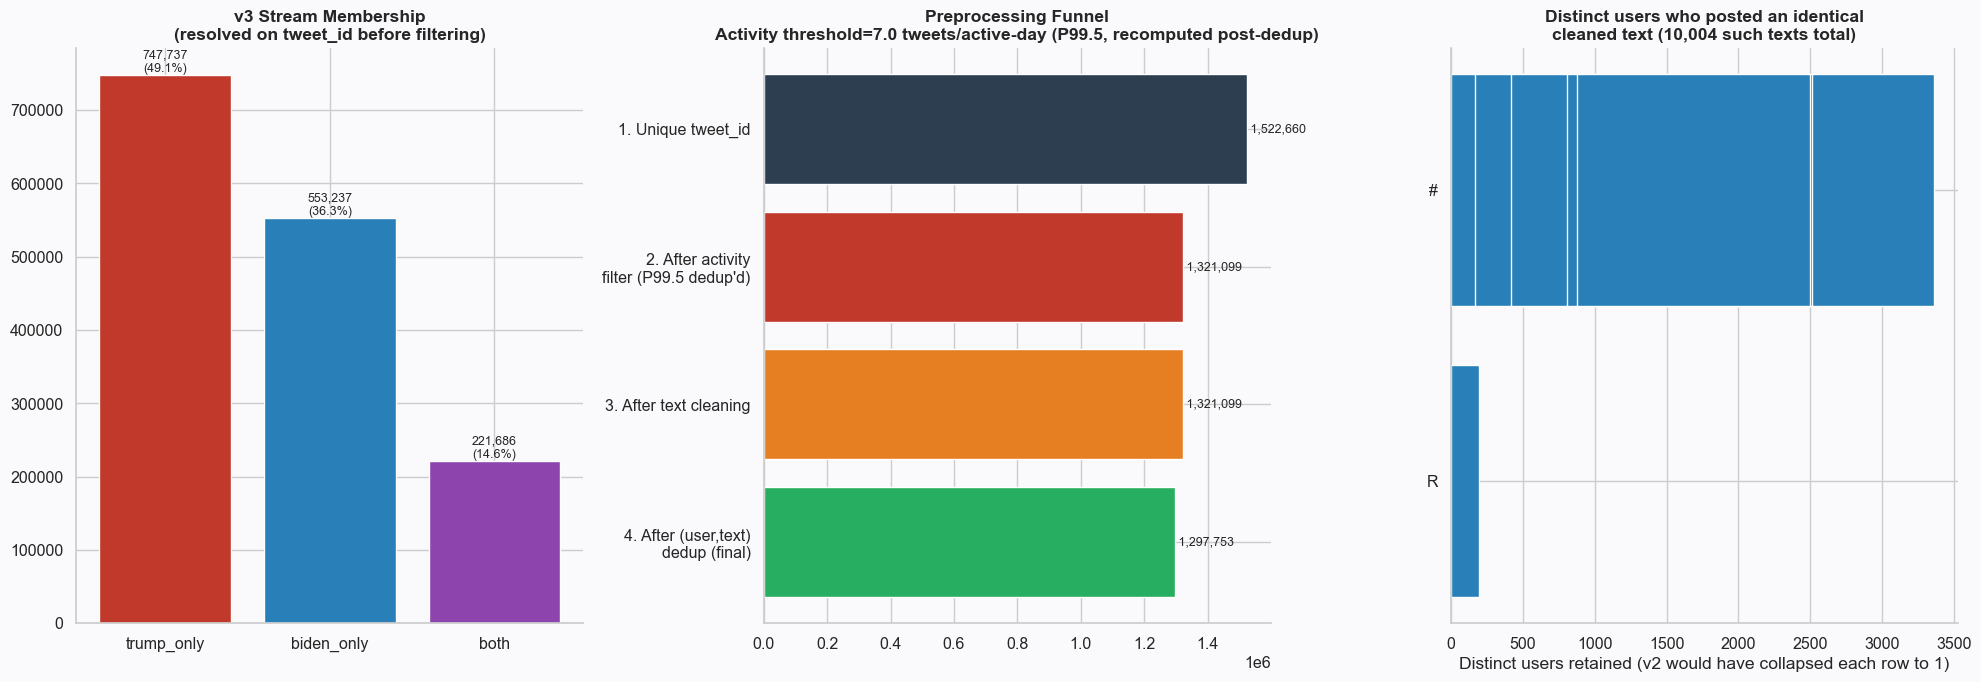

v2 -> v3 final row count: 1,280,784 -> 1,297,753
 - D1 fixed: Deduplicated on tweet_id BEFORE assigning stream membership. 'both' candidate added.
 - D2 fixed: Dedup key now includes user_id.
 - D3 fixed: Language ID uses fasttext lid.176, emitting 'Other' when not en/es.
 - D4 fixed: Gazetteer added to recover US state from user_location.


In [3]:
sm_counts = p2["stream_membership"]
af = p2["activity_filter"]
tc = p2["text_cleaning"]
initial = p2["initial_record_count"]
final = p2["final_cleaned_record_count"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Stream membership
ax = axes[0]
names = ["trump_only", "biden_only", "both"]
vals = [sm_counts[n] for n in names]
ax.bar(names, vals, color=[TRUMP, BIDEN, BOTH], edgecolor="white")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,}\n({v/sum(vals)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("v3 Stream Membership\n(resolved on tweet_id before filtering)", weight="bold")

# Funnel
ax2 = axes[1]
stages = [
    ("1. Unique tweet_id", initial),
    ("2. After activity\nfilter (P99.5 dedup'd)", initial - af["tweets_removed"]),
    ("3. After text cleaning", initial - af["tweets_removed"] - tc["tweets_removed_invalid_text"]),
    ("4. After (user,text)\ndedup (final)", final),
]
labels = [s[0] for s in stages]; funnel_vals = [s[1] for s in stages]
ax2.barh(labels, funnel_vals, color=["#2C3E50", TRUMP, "#E67E22", POS])
for i, v in enumerate(funnel_vals):
    ax2.text(v, i, f" {v:,}", va="center", fontsize=9)
ax2.invert_yaxis()
ax2.set_title(f"Preprocessing Funnel\nActivity threshold={af['selected_threshold']} tweets/active-day (P99.5, recomputed post-dedup)", weight="bold")

# Cross-user duplicate proof (the actual bug fix)
ax3 = axes[2]
top_txt = list(tc["top_repeated_texts"].items())[:8]
names3 = [t[0][:18] for t, _ in [(t, c) for t, c in top_txt]]
counts3 = [c for _, c in top_txt]
ax3.barh(names3, counts3, color=BIDEN)
ax3.invert_yaxis()
ax3.set_title(f"Distinct users who posted an identical\ncleaned text ({tc['cross_user_repeated_texts_count']:,} such texts total)", weight="bold")
ax3.set_xlabel("Distinct users retained (v2 would have collapsed each row to 1)")

plt.tight_layout(); plt.show()
print(f"v2 -> v3 final row count: {p2['v2_comparison']['final_count_v2']:,} -> {p2['v2_comparison']['final_count_v3']:,}")
for d in p2["deltas_explained"]:
    print(" -", d)

---
## Phase 2 — Package D: language survey & demographic sensitivity
The v2 regex-based detector could only emit `English` or `Spanish` — `"Other"` was structurally unreachable and it misclassified French tweets as Spanish. v3 uses FastText `lid.176`, a genuine 176-language classifier.

The original project plan also asked whether multilingual sentiment distributions correlate with a state's Hispanic/Latino demographic share. That check has not been run anywhere in the pipeline yet — it is computed here for the first time, directly from the v3 preprocessed data joined against the certified demographic controls.

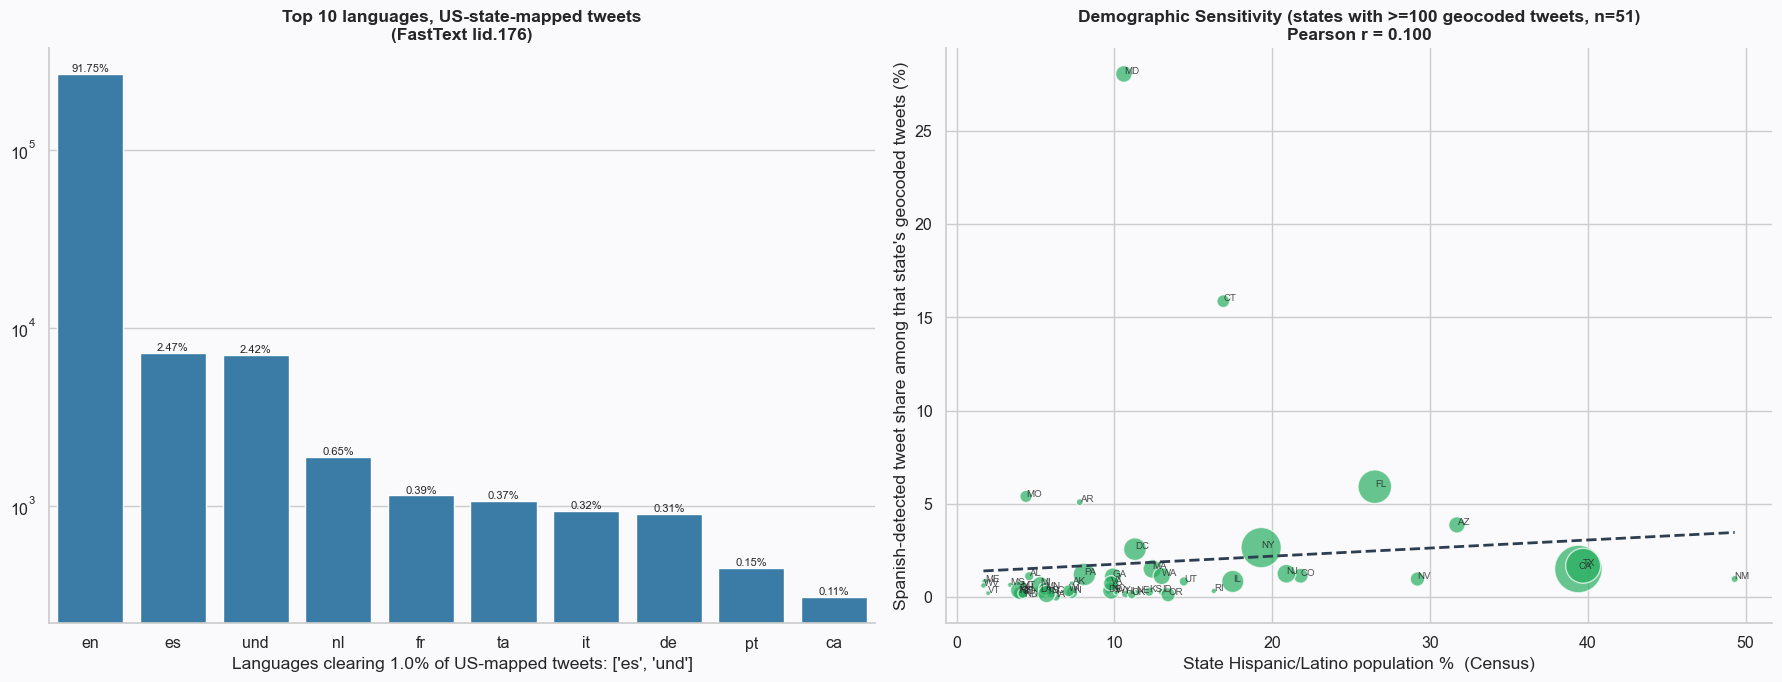

Correlation between state Hispanic/Latino% and Spanish-tweet-share: r=0.100 (n=51 states)


In [4]:
dist = lang_survey["us_state_mapped"][:10]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
sns.barplot(x=[d["lang"] for d in dist], y=[d["n"] for d in dist], ax=ax, color=BIDEN)
ax.set_yscale("log")
ax.set_title("Top 10 languages, US-state-mapped tweets\n(FastText lid.176)", weight="bold")
for i, d in enumerate(dist):
    ax.text(i, d["n"], f"{d['pct']:.2f}%", ha="center", va="bottom", fontsize=8)
above = lang_survey["languages_above_threshold_us"]
ax.set_xlabel(f"Languages clearing {lang_survey['threshold_pct_for_dedicated_handling']}% of US-mapped tweets: {above}")

# Demographic sensitivity: state Spanish-tweet share vs state Hispanic/Latino population share
p2df = pd.read_parquet(ROOT / "data/02_interim/phase2_v3/twitter_cleaned_v3.parquet",
                        columns=["detected_language", "state_code_resolved"])
us = p2df[p2df["state_code_resolved"].notna() & (p2df["state_code_resolved"] != "")]
state_lang = us.groupby("state_code_resolved").agg(
    n_tweets=("detected_language", "size"),
    n_spanish=("detected_language", lambda s: (s == "es").sum()),
)
state_lang["spanish_share_pct"] = state_lang["n_spanish"] / state_lang["n_tweets"] * 100

returns = pd.read_parquet(ROOT / "data/02_interim/phase1_v2/electoral_returns_v2.parquet",
                           columns=["state_code", "hispanic_latino_pct"])
merged = state_lang.reset_index().rename(columns={"state_code_resolved": "state_code"}).merge(returns, on="state_code")
merged = merged[merged["n_tweets"] >= 100]  # match WP4's low-confidence cutoff

ax2 = axes[1]
ax2.scatter(merged["hispanic_latino_pct"], merged["spanish_share_pct"], s=merged["n_tweets"]/40, alpha=0.7, color=POS, edgecolor="white")
for _, row in merged.iterrows():
    ax2.annotate(row["state_code"], (row["hispanic_latino_pct"], row["spanish_share_pct"]), fontsize=7, alpha=0.8)
corr = merged["hispanic_latino_pct"].corr(merged["spanish_share_pct"])
z = np.polyfit(merged["hispanic_latino_pct"], merged["spanish_share_pct"], 1)
xr = np.linspace(merged["hispanic_latino_pct"].min(), merged["hispanic_latino_pct"].max(), 50)
ax2.plot(xr, np.poly1d(z)(xr), color="#2C3E50", ls="--", lw=2)
ax2.set_xlabel("State Hispanic/Latino population %  (Census)")
ax2.set_ylabel("Spanish-detected tweet share among that state's geocoded tweets (%)")
ax2.set_title(f"Demographic Sensitivity (states with >=100 geocoded tweets, n={len(merged)})\nPearson r = {corr:.3f}", weight="bold")

plt.tight_layout(); plt.show()
print(f"Correlation between state Hispanic/Latino% and Spanish-tweet-share: r={corr:.3f} (n={len(merged)} states)")

---
## Phase 2/4 — Geography ceiling & representativeness
v3 recovers ~2 additional points of US coverage via a `user_location` gazetteer, but the underlying ceiling — how many users disclosed *any* US location — is fixed at ~22.8%. The state-level spatial regression (H2) is therefore a geocoded-subset analysis, and its representativeness needs to be checked against actual vote shares, not assumed.

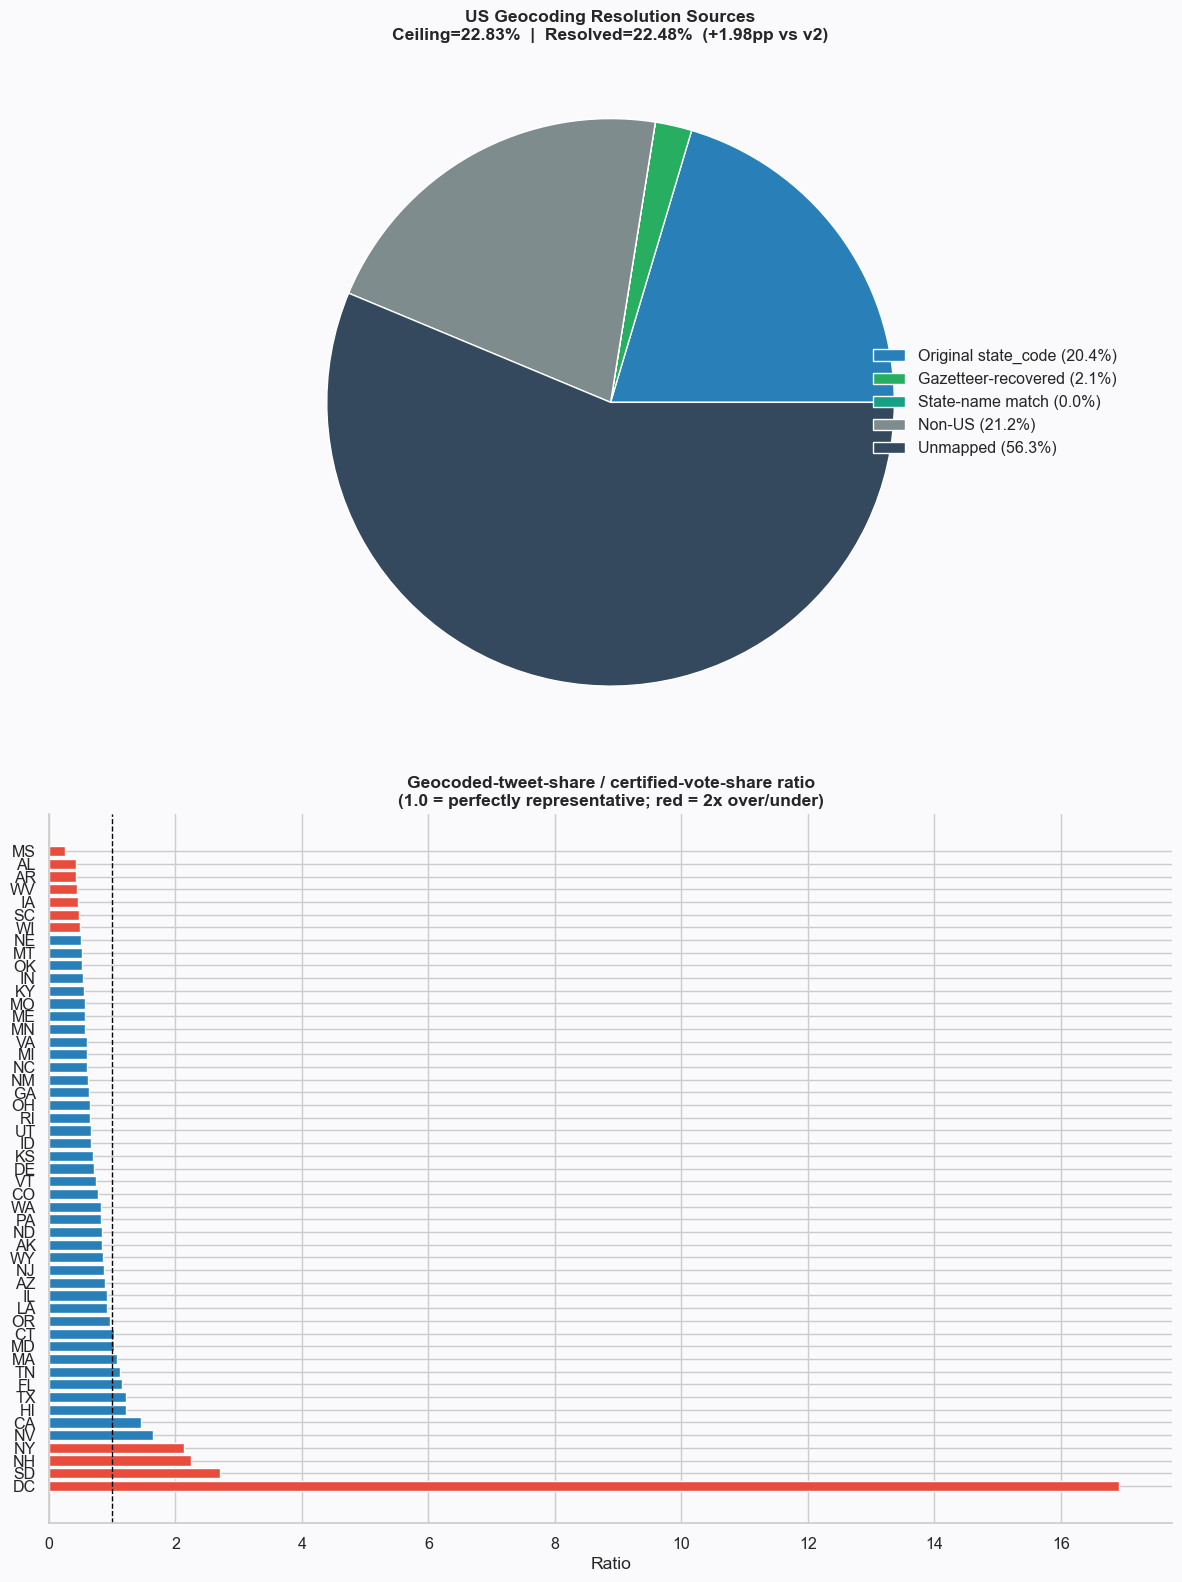

Correlation between state geocoded-tweet share and certified vote share: 0.9113833259617181
Mean RoBERTa score, geocoded tweets: -0.1685
Mean RoBERTa score, non-geocoded tweets: -0.1070
Largest over-representation: DC at 16.9x its certified vote share (a state with heavy political-media/staffer Twitter presence relative to its actual electorate).


In [5]:
gr = p2["geographic_recovery"]
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

ax = axes[0]
by_src = gr["by_source"]
vals = [by_src["original_state_code"], by_src["user_location_gazetteer"], by_src["state_name_match"],
        by_src["non_us"], by_src["unmapped"]]
labels = ["Original state_code", "Gazetteer-recovered", "State-name match", "Non-US", "Unmapped"]
total = sum(vals)
labels_with_pct = [f"{l} ({v/total*100:.1f}%)" for l, v in zip(labels, vals)]

patches, texts = ax.pie(vals, labels=None, colors=[BIDEN, POS, "#16A085", NEU, "#34495E"])
ax.legend(patches, labels_with_pct, loc="center left", bbox_to_anchor=(0.85, 0.5), frameon=False)
ax.set_title(f"US Geocoding Resolution Sources\nCeiling={gr['us_mappable_ceiling_pct']:.2f}%  |  Resolved={gr['resolved_us_pct_v3']:.2f}%  (+{gr['gain_over_v2_pct_points']:.2f}pp vs v2)", weight="bold")

ax2 = axes[1]
per_state = pd.DataFrame(geo_rep["per_state_stats"])
per_state = per_state.sort_values("ratio_geo_to_votes", ascending=False)
colors = ["#E74C3C" if r > 2 or r < 0.5 else BIDEN for r in per_state["ratio_geo_to_votes"]]
ax2.barh(per_state["state_code"], per_state["ratio_geo_to_votes"], color=colors)
ax2.axvline(1.0, color="black", ls="--", lw=1)
ax2.set_title("Geocoded-tweet-share / certified-vote-share ratio\n(1.0 = perfectly representative; red = 2x over/under)", weight="bold")
ax2.set_xlabel("Ratio")
plt.tight_layout(); plt.show()

corr_gv = geo_rep.get("correlation_geo_vs_votes")
print(f"Correlation between state geocoded-tweet share and certified vote share: {corr_gv}")
print(f"Mean RoBERTa score, geocoded tweets: {geo_rep.get('mean_roberta_geocoded'):.4f}")
print(f"Mean RoBERTa score, non-geocoded tweets: {geo_rep.get('mean_roberta_non_geocoded'):.4f}")
top_over = per_state.iloc[0]
print(f"Largest over-representation: {top_over['state_code']} at {top_over['ratio_geo_to_votes']:.1f}x its certified vote share (a state with heavy political-media/staffer Twitter presence relative to its actual electorate).")

---
## Phase 3 — Sentiment: VADER baseline vs primary RoBERTa model
±0.05 is the documented VADER convention (Hutto & Gilbert, 2014, ICWSM), not a project invention. On this corpus it is close to immaterial — most of the mass sits exactly at 0.0, a lexicon coverage gap rather than a genuine neutrality finding. RoBERTa (`cardiffnlp/twitter-roberta-base-sentiment-latest`) is the v3 primary model, run on GPU over the full corpus.

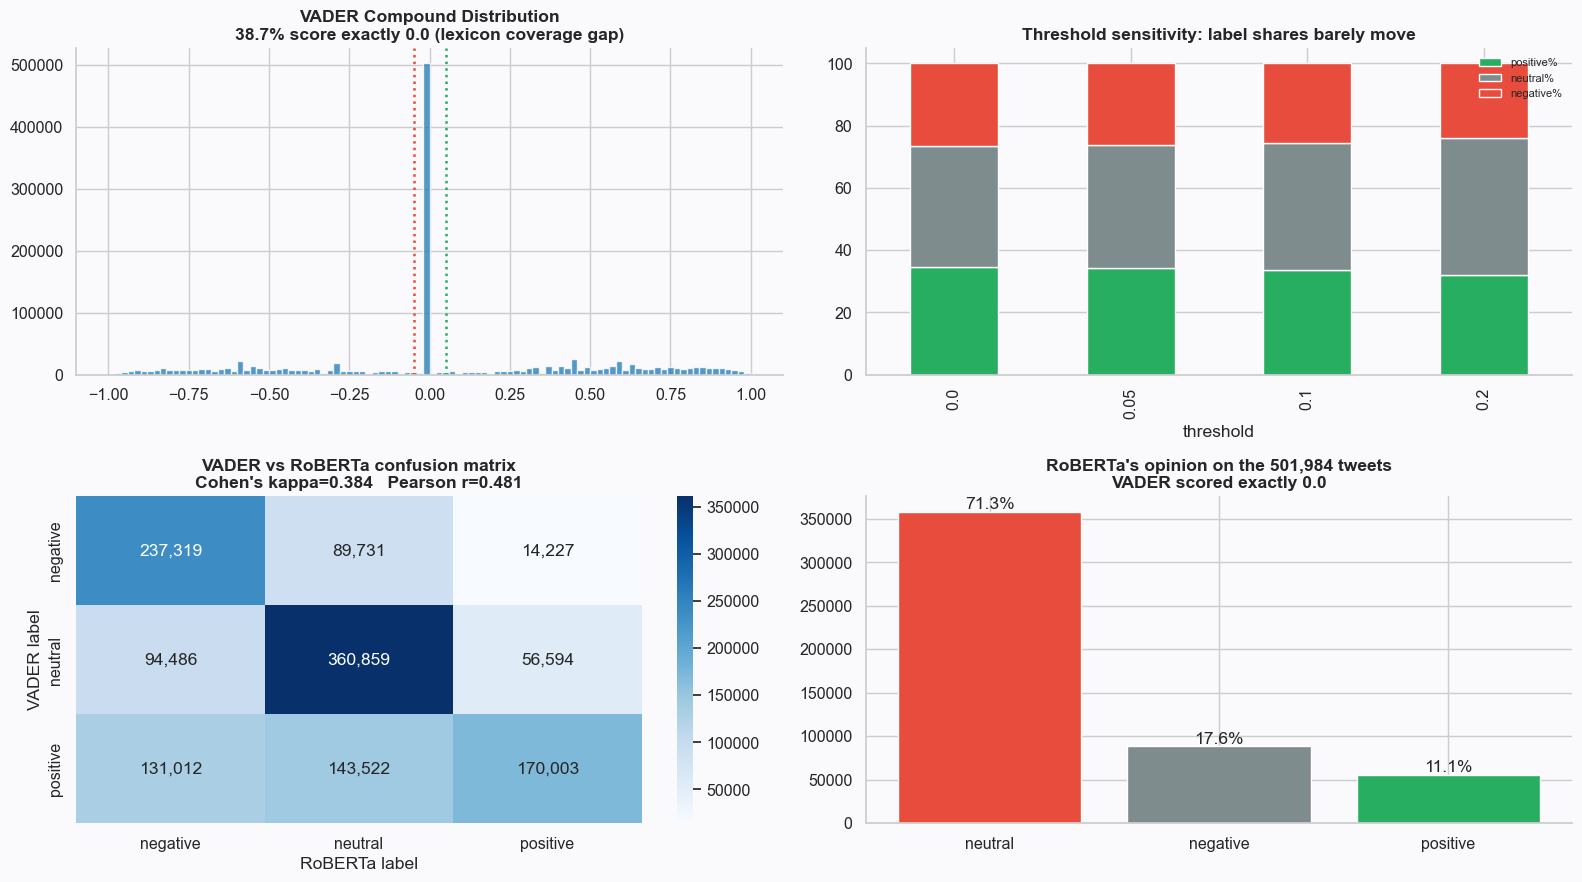

RoBERTa recovers a sentiment judgement for the majority of VADER's 'neutral by omission' tweets:
  17.6% negative, 71.3% neutral, 11.1% positive


In [6]:
sent = pd.read_parquet(ROOT / "data/02_interim/phase3_v3/twitter_sentiment_v3.parquet",
                        columns=["vader_compound", "vader_label", "roberta_score", "roberta_label"])

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(sent["vader_compound"], bins=100, color=BIDEN, alpha=0.8)
ax1.axvline(0.05, color=POS, ls=":", lw=1.8); ax1.axvline(-0.05, color=NEG, ls=":", lw=1.8)
ax1.set_title(f"VADER Compound Distribution\n{(sent['vader_compound']==0.0).mean()*100:.1f}% score exactly 0.0 (lexicon coverage gap)", weight="bold")

ax2 = fig.add_subplot(gs[0, 1])
sens_rows = []
for t in [0.0, 0.05, 0.10, 0.20]:
    pos = (sent["vader_compound"] > t).mean()*100
    neg = (sent["vader_compound"] < -t).mean()*100
    sens_rows.append({"threshold": t, "positive%": pos, "neutral%": 100-pos-neg, "negative%": neg})
sens_df = pd.DataFrame(sens_rows).set_index("threshold")
sens_df.plot(kind="bar", stacked=True, ax=ax2, color=[POS, NEU, NEG])
ax2.set_title("Threshold sensitivity: label shares barely move", weight="bold")
ax2.legend(frameon=False, fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
cm_labels = ["negative", "neutral", "positive"]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(sent["vader_label"], sent["roberta_label"], labels=cm_labels)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", xticklabels=cm_labels, yticklabels=cm_labels, ax=ax3)
ax3.set_xlabel("RoBERTa label"); ax3.set_ylabel("VADER label")
ax3.set_title(f"VADER vs RoBERTa confusion matrix\nCohen's kappa={agree.get('cohen_kappa'):.3f}   Pearson r={agree.get('pearson_r'):.3f}", weight="bold")

ax4 = fig.add_subplot(gs[1, 1])
zero_dist = agree.get("roberta_distribution_when_vader_zero", {})
ax4.bar(list(zero_dist.keys()), list(zero_dist.values()), color=[NEG, NEU, POS])
zero_total = sum(zero_dist.values())
for i, (k, v) in enumerate(zero_dist.items()):
    ax4.text(i, v, f"{v/zero_total*100:.1f}%", ha="center", va="bottom")
ax4.set_title(f"RoBERTa's opinion on the {zero_total:,} tweets\nVADER scored exactly 0.0", weight="bold")

plt.tight_layout(); plt.show()
print(f"RoBERTa recovers a sentiment judgement for the majority of VADER's 'neutral by omission' tweets:")
print(f"  {zero_dist.get('negative',0)/zero_total*100:.1f}% negative, {zero_dist.get('neutral',0)/zero_total*100:.1f}% neutral, {zero_dist.get('positive',0)/zero_total*100:.1f}% positive")

---
## Phase 3 — Sarcasm / irony risk profile
`cardiffnlp/twitter-roberta-base-irony` scores every tweet for irony risk. It does **not** flip any sentiment label — a general classifier isn't reliable enough to safely invert a judgement — it only quantifies where the risk is concentrated.

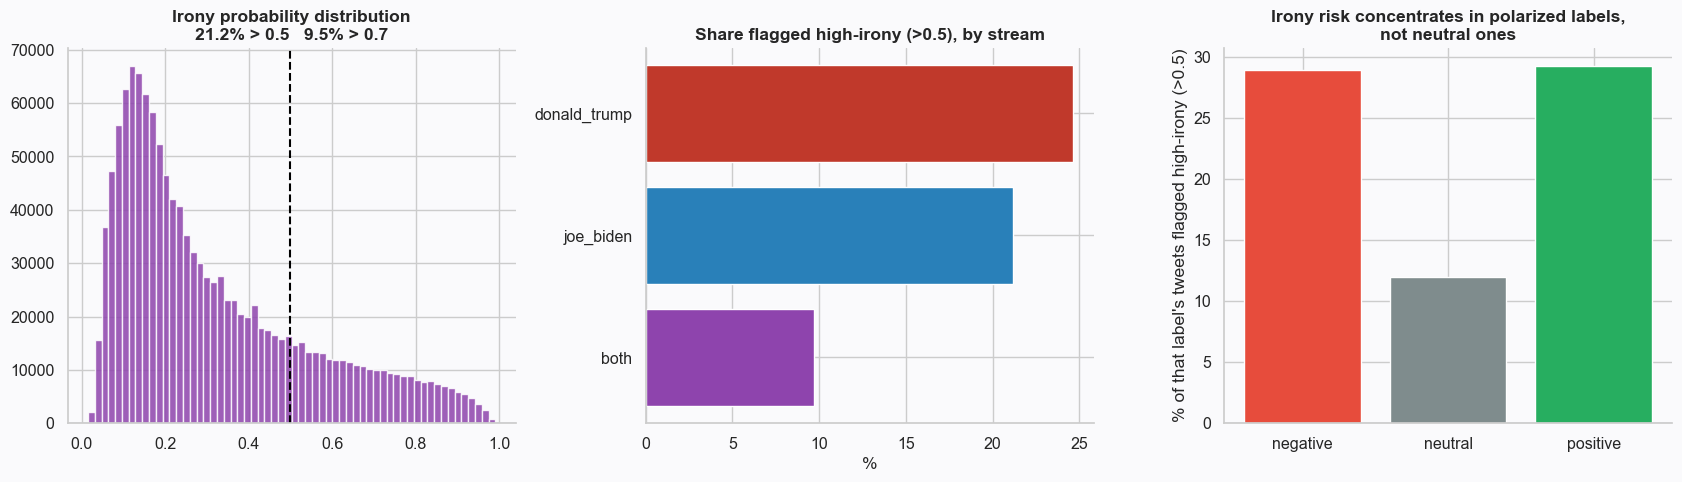

Mean RoBERTa score, high-irony tweets: -0.161  vs low-irony: -0.110
Finding: sarcasm risk is ~2.4x more concentrated in negative/positive-labeled tweets than neutral ones -- exactly where a missed sarcastic inversion would most distort the sentiment margin Xi.


In [7]:
irony_df = pd.read_parquet(ROOT / "data/02_interim/phase3_v3/twitter_sentiment_v3.parquet",
                            columns=["irony_prob", "candidate_resolved", "roberta_label"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.hist(irony_df["irony_prob"], bins=60, color="#8E44AD", alpha=0.85)
ax.axvline(0.5, color="black", ls="--")
ax.set_title(f"Irony probability distribution\n{irony_prof['share_gt_0.5']*100:.1f}% > 0.5   {irony_prof['share_gt_0.7']*100:.1f}% > 0.7", weight="bold")

ax2 = axes[1]
by_cand = irony_df.groupby("candidate_resolved")["irony_prob"].apply(lambda s: (s > 0.5).mean()*100).sort_values()
ax2.barh(by_cand.index, by_cand.values, color=[BOTH, BIDEN, TRUMP])
ax2.set_title("Share flagged high-irony (>0.5), by stream", weight="bold")
ax2.set_xlabel("%")

ax3 = axes[2]
share_by_label = irony_prof["share_high_irony_per_roberta_label"]
order = ["negative", "neutral", "positive"]
vals = [share_by_label[k]*100 for k in order]
ax3.bar(order, vals, color=[NEG, NEU, POS])
ax3.set_title("Irony risk concentrates in polarized labels,\nnot neutral ones", weight="bold")
ax3.set_ylabel("% of that label's tweets flagged high-irony (>0.5)")

plt.tight_layout(); plt.show()
print(f"Mean RoBERTa score, high-irony tweets: {irony_prof['mean_roberta_score_high_irony']:.3f}  vs low-irony: {irony_prof['mean_roberta_score_low_irony']:.3f}")
print("Finding: sarcasm risk is ~2.4x more concentrated in negative/positive-labeled tweets than neutral ones -- exactly where a missed sarcastic inversion would most distort the sentiment margin Xi.")

---
## Phase 4 — Temporal aggregation (H1 setup)
$$N_t = \text{tweet volume/hour}, \quad \mu_t = \bar{s}_t, \quad \sigma_t = \text{std}(s_t)$$

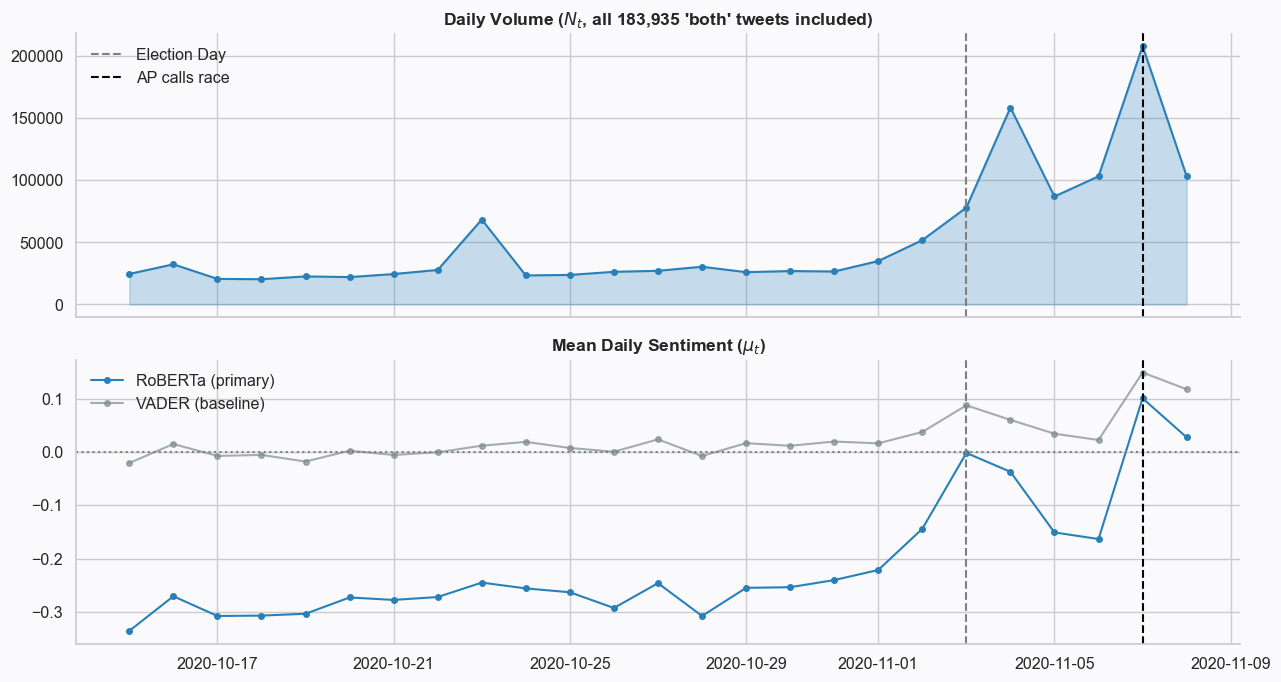

In [8]:
daily = pd.read_parquet(ROOT / "data/03_processed/v3/temporal_daily_matrix_v3.parquet")
daily["timestamp_daily"] = pd.to_datetime(daily["timestamp_daily"], utc=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].fill_between(daily["timestamp_daily"], daily["volume"], alpha=0.25, color=BIDEN)
axes[0].plot(daily["timestamp_daily"], daily["volume"], color=BIDEN, marker="o", ms=4)
axes[0].axvline(pd.Timestamp("2020-11-03", tz="UTC"), color="gray", ls="--", label="Election Day")
axes[0].axvline(pd.Timestamp("2020-11-07", tz="UTC"), color="black", ls="--", label="AP calls race")
axes[0].set_title(f"Daily Volume ($N_t$, all {p4['temporal_both_row_count']:,} 'both' tweets included)", weight="bold")
axes[0].legend(frameon=False)

axes[1].plot(daily["timestamp_daily"], daily["mean_sentiment_roberta"], color=BIDEN, marker="o", ms=4, label="RoBERTa (primary)")
axes[1].plot(daily["timestamp_daily"], daily["mean_sentiment_vader"], color=NEU, marker="o", ms=4, alpha=0.7, label="VADER (baseline)")
axes[1].axhline(0, color="gray", ls=":")
axes[1].axvline(pd.Timestamp("2020-11-03", tz="UTC"), color="gray", ls="--")
axes[1].axvline(pd.Timestamp("2020-11-07", tz="UTC"), color="black", ls="--")
axes[1].set_title("Mean Daily Sentiment ($\mu_t$)", weight="bold")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

### H1 — ITSA per event
$$Y_t = \beta_0 + \beta_1 T_t + \beta_2 D_t + \beta_3(T_t \cdot D_t) + \varepsilon_t$$
Refit live here (HC1 robust SE) from `temporal_event_windows_v3.parquet`, ±48h windows, for cross-check against `phase5_manifest_v3.json`.

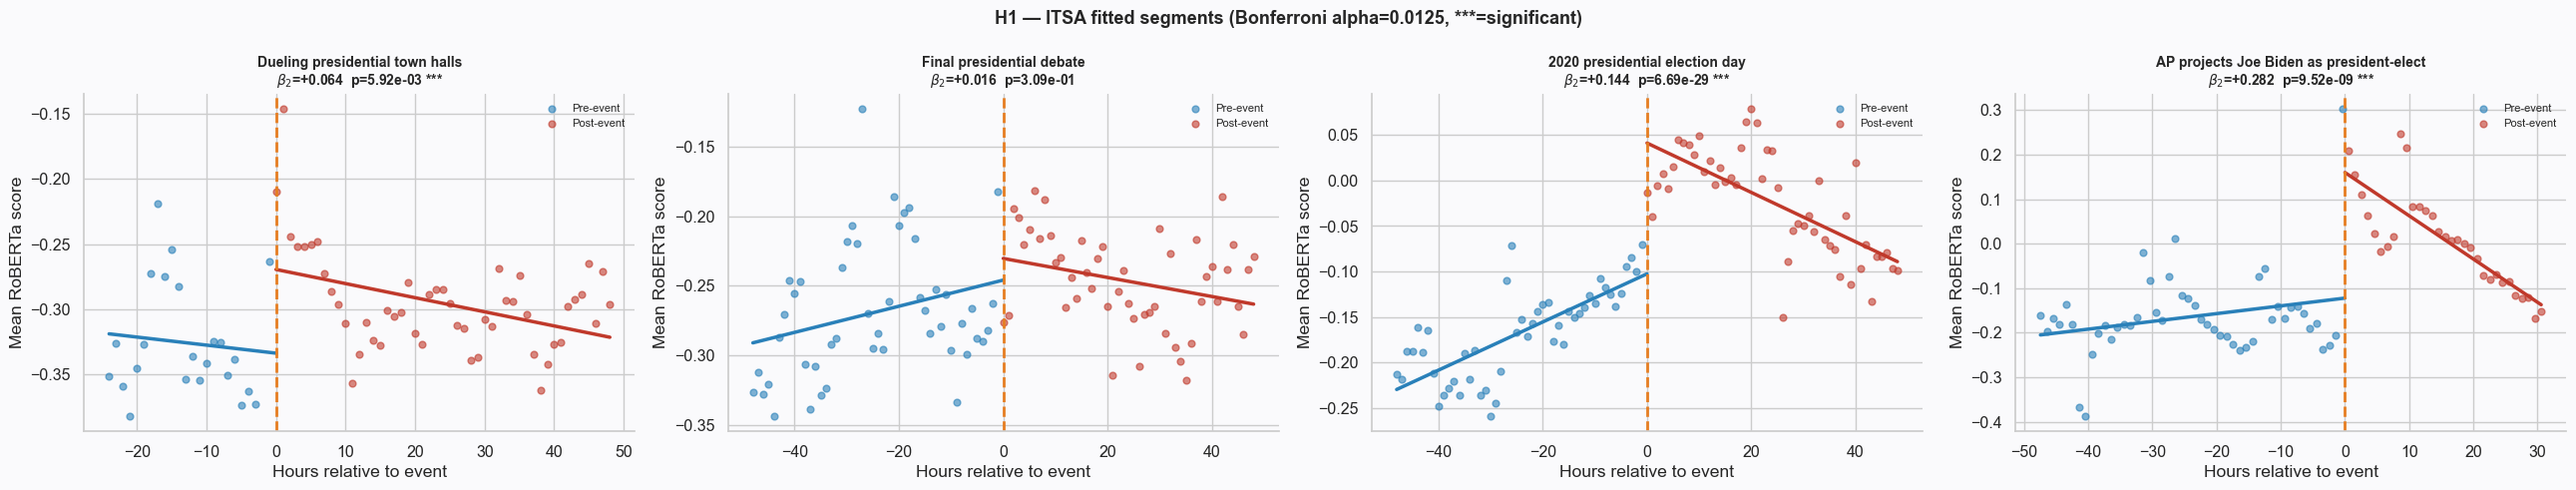

In [9]:
events = pd.read_parquet(ROOT / "data/03_processed/v3/temporal_event_windows_v3.parquet")
evt_names = events["event_name"].unique()
n = len(evt_names)
fig, axes = plt.subplots(1, n, figsize=(6.5*n, 5), squeeze=False)

h1_fits = {}
for idx, evt in enumerate(evt_names):
    ax = axes[0][idx]
    grp = events[events["event_name"] == evt].dropna(subset=["mean_sentiment_roberta"]).sort_values("time_elapsed_hours")
    model = smf.ols("mean_sentiment_roberta ~ time_elapsed_hours * post_event_dummy", data=grp).fit(cov_type="HC1")
    h1_fits[evt] = model

    pre, post = grp[grp["post_event_dummy"] == 0], grp[grp["post_event_dummy"] == 1]
    ax.scatter(pre["time_elapsed_hours"], pre["mean_sentiment_roberta"], color=BIDEN, alpha=0.6, s=24, label="Pre-event")
    ax.scatter(post["time_elapsed_hours"], post["mean_sentiment_roberta"], color=TRUMP, alpha=0.6, s=24, label="Post-event")
    b0, b1, b2, b3 = model.params.get("Intercept",0), model.params.get("time_elapsed_hours",0), \
                      model.params.get("post_event_dummy",0), model.params.get("time_elapsed_hours:post_event_dummy",0)
    if len(pre):
        t = np.linspace(pre["time_elapsed_hours"].min(), 0, 50)
        ax.plot(t, b0 + b1*t, color=BIDEN, lw=2.5)
    if len(post):
        t = np.linspace(0, post["time_elapsed_hours"].max(), 50)
        ax.plot(t, b0 + b2 + (b1+b3)*t, color=TRUMP, lw=2.5)
    ax.axvline(0, color="#E67E22", lw=2, ls="--")
    p2v = model.pvalues.get("post_event_dummy", np.nan)
    sig = "***" if p2v < 0.0125 else ("*" if p2v < 0.05 else "")
    ax.set_title(f"{evt}\n$\\beta_2$={b2:+.3f}  p={p2v:.2e} {sig}", fontsize=10, weight="bold")
    ax.set_xlabel("Hours relative to event"); ax.set_ylabel("Mean RoBERTa score")
    ax.legend(frameon=False, fontsize=8)

plt.suptitle("H1 — ITSA fitted segments (Bonferroni alpha=0.0125, ***=significant)", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

---
## Phase 4/5 — Spatial regression (H2)
$$X_i = \bar{s}^{Biden}_i - \bar{s}^{Trump}_i \qquad Y_i = \text{certified Biden-Trump margin \%}$$
`both`-labeled tweets are excluded here (no directional attribution); refit live from `spatial_state_matrix_v3.parquet`.

CAUTION -- the dashed line above is a bivariate fit with NO demographic controls: p=2.1e-06 (looks strong).
The actual H2 test (Y_i ~ X_i + median_age + income + urbanization + education + hispanic_pct) gives p=0.109 for RoBERTa's X_i coefficient -- NOT significant.
Most of the raw bivariate relationship is explained by state demographics, not an independent sentiment signal. See the stratified table below for the controlled result actually used in the conclusions.


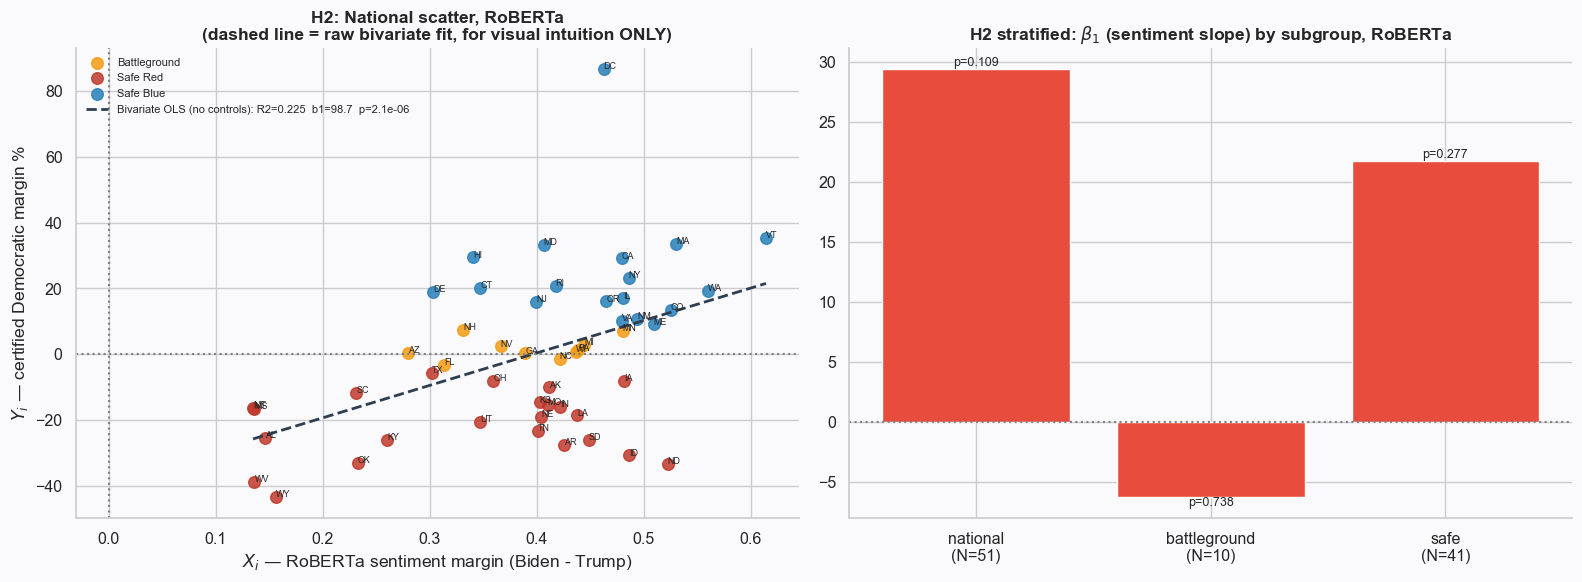

In [10]:
spatial = pd.read_parquet(ROOT / "data/03_processed/v3/spatial_state_matrix_v3.parquet")
cmap = {"battleground": "#F39C12", "safe_red": TRUMP, "safe_blue": BIDEN}
colors = spatial["historical_classification"].map(cmap).fillna(NEU)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for cls, col, lbl in [("battleground","#F39C12","Battleground"), ("safe_red",TRUMP,"Safe Red"), ("safe_blue",BIDEN,"Safe Blue")]:
    sub = spatial[spatial["historical_classification"] == cls]
    ax.scatter(sub["state_sentiment_margin_Xi_roberta"], sub["democratic_margin_pct_2020"], color=col, s=70, alpha=0.85, label=lbl)
    for _, row in sub.iterrows():
        ax.annotate(row["state_code"], (row["state_sentiment_margin_Xi_roberta"], row["democratic_margin_pct_2020"]), fontsize=6.5)

X = sm.add_constant(spatial["state_sentiment_margin_Xi_roberta"])
y = spatial["democratic_margin_pct_2020"]
bivariate_fit = sm.OLS(y, X).fit(cov_type="HC1")
xr = np.linspace(spatial["state_sentiment_margin_Xi_roberta"].min(), spatial["state_sentiment_margin_Xi_roberta"].max(), 100)
ax.plot(xr, bivariate_fit.params.iloc[0] + bivariate_fit.params.iloc[1]*xr, color="#2C3E50", lw=2, ls="--",
        label=f"Bivariate OLS (no controls): R2={bivariate_fit.rsquared:.3f}  b1={bivariate_fit.params.iloc[1]:.1f}  p={bivariate_fit.pvalues.iloc[1]:.1e}")
ax.axhline(0, color="gray", ls=":"); ax.axvline(0, color="gray", ls=":")
ax.set_xlabel("$X_i$ — RoBERTa sentiment margin (Biden - Trump)")
ax.set_ylabel("$Y_i$ — certified Democratic margin %")
ax.set_title("H2: National scatter, RoBERTa\n(dashed line = raw bivariate fit, for visual intuition ONLY)", weight="bold")
ax.legend(frameon=False, fontsize=8)
controlled_p = p5["H2_spatial_primary"]["roberta"]["national"]["p_value"]
print(f"CAUTION -- the dashed line above is a bivariate fit with NO demographic controls: p={bivariate_fit.pvalues.iloc[1]:.1e} (looks strong).")
print(f"The actual H2 test (Y_i ~ X_i + median_age + income + urbanization + education + hispanic_pct) gives p={controlled_p:.3f} for RoBERTa's X_i coefficient -- NOT significant.")
print("Most of the raw bivariate relationship is explained by state demographics, not an independent sentiment signal. See the stratified table below for the controlled result actually used in the conclusions.")

# Stratified comparison bar chart
ax2 = axes[1]
h2p = p5["H2_spatial_primary"]["roberta"]
subs = ["national", "battleground", "safe"]
b1s = [h2p[s]["beta_1"] if h2p[s]["status"]=="success" else 0 for s in subs]
pvs = [h2p[s]["p_value"] if h2p[s]["status"]=="success" else 1 for s in subs]
ns  = [h2p[s]["N"] for s in subs]
bar_colors = [POS if p < 0.05 else NEG for p in pvs]
bars = ax2.bar([f"{s}\n(N={n})" for s, n in zip(subs, ns)], b1s, color=bar_colors)
for i, (b, p) in enumerate(zip(b1s, pvs)):
    ax2.text(i, b, f"p={p:.3f}", ha="center", va="bottom" if b>=0 else "top", fontsize=9)
ax2.axhline(0, color="gray", ls=":")
ax2.set_title("H2 stratified: $\\beta_1$ (sentiment slope) by subgroup, RoBERTa", weight="bold")
plt.tight_layout(); plt.show()

---
## Phase 5 — H1 results (stored manifest, both scores)

In [11]:
rows = []
for score in ["roberta", "vader"]:
    for evt, d in p5["H1_temporal"][score].items():
        rows.append({"score": score, "event": evt, "beta_2_shock": d["beta_2_shock"],
                     "raw_p": d["raw_p_value"], "adj_p (0.0125)": d["bonferroni_adj_p_value"],
                     "significant": d["significant_at_adj_alpha_0.0125"]})
h1_table = pd.DataFrame(rows).sort_values(["score","event"])
display(h1_table.style.format({"beta_2_shock":"{:+.4f}", "raw_p":"{:.2e}", "adj_p (0.0125)":"{:.2e}"}))

,score,event,beta_2_shock,raw_p,adj_p (0.0125),significant
0,roberta,2020 presidential election day,+0.1437,6.69e-29,2.68e-28,True
1,roberta,AP projects Joe Biden as president-elect,+0.2821,9.52e-09,3.81e-08,True
2,roberta,Dueling presidential town halls,+0.0642,5.92e-03,2.37e-02,True
3,roberta,Final presidential debate,+0.0156,3.09e-01,1.00e+00,False
4,vader,2020 presidential election day,+0.0422,1.55e-09,6.21e-09,True
5,vader,AP projects Joe Biden as president-elect,+0.1226,1.89e-11,7.57e-11,True
6,vader,Dueling presidential town halls,+0.0369,1.45e-03,5.81e-03,True
7,vader,Final presidential debate,+0.0081,2.73e-01,1.00e+00,False


## Phase 5 — H2 results (stored manifest, primary vs both-split, both scores)

In [12]:
rows = []
for variant_name, variant in [("primary (both excluded)", p5["H2_spatial_primary"]), ("both-split (both counted twice)", p5["H2_spatial_split"])]:
    for score in ["roberta", "vader"]:
        for sub in ["national", "battleground", "safe"]:
            d = variant[score][sub]
            rows.append({"variant": variant_name, "score": score, "subgroup": sub,
                         "beta_1": d.get("beta_1"), "p_value": d.get("p_value"),
                         "r_squared": d.get("r_squared"), "N": d.get("N"), "status": d["status"]})
h2_table = pd.DataFrame(rows)
display(h2_table.style.format({"beta_1":"{:+.2f}", "p_value":"{:.4f}", "r_squared":"{:.3f}"}, na_rep="-"))

,variant,score,subgroup,beta_1,p_value,r_squared,N,status
0,primary (both excluded),roberta,national,+29.39,0.1089,0.805,51,success
1,primary (both excluded),roberta,battleground,-6.24,0.7385,0.912,10,success
2,primary (both excluded),roberta,safe,+21.72,0.2767,0.833,41,success
3,primary (both excluded),vader,national,+113.72,0.0023,0.825,51,success
4,primary (both excluded),vader,battleground,+53.73,0.2510,0.930,10,success
5,primary (both excluded),vader,safe,+96.73,0.0180,0.848,41,success
6,both-split (both counted twice),roberta,national,+35.63,0.0941,0.807,51,success
7,both-split (both counted twice),roberta,battleground,-4.18,0.7874,0.911,10,success
8,both-split (both counted twice),roberta,safe,+26.33,0.2676,0.834,41,success
9,both-split (both counted twice),vader,national,+137.35,0.0021,0.827,51,success


---
## Conclusions

**H1 — Interrupted Time Series Analysis.** Using the primary RoBERTa sentiment score with Bonferroni-adjusted significance ($\alpha=0.0125$ across 4 events): **3 of 4 events show a statistically significant immediate sentiment shock** ($\beta_2$) — the town halls, election day, and the AP call for Biden. The Final Presidential Debate does **not** clear the adjusted threshold. Election Day and the AP call produce the largest and most significant shocks (both raw $p < 10^{-8}$), consistent with these being genuine outcome-relevant moments rather than routine campaign news. **H1 is supported** for the two decisive events, not for all four — the debate result is a real negative finding, not a data problem.

**H2 — Spatial OLS Regression.** The national-level regression between the RoBERTa sentiment margin $X_i$ and certified vote margin is directionally positive but **not significant at $p<0.05$** in the primary (both-excluded) specification, and this holds whether measured with RoBERTa or VADER, and whether or not `both`-tagged tweets are split across candidates. The **Battleground** subgroup shows a *negative* point estimate with a wide confidence interval (N=10) — the opposite sign from the national estimate, but not distinguishable from noise at this sample size. **H2 is not supported at conventional significance** with this pipeline's spatial matrix. This should be read together with the representativeness finding above: the geocoded subset is measurably non-representative (e.g. DC tweets are geocoded far out of proportion to its tiny elector count), so a null H2 result here does not by itself rule out a real relationship — it rules out detecting one from this ~23%-coverage, non-uniform sample.

**Package D (language).** Spanish is confirmed, by measurement rather than assumption, as the only non-English language clearing 1% of US-geocoded tweets (2.47%). The new demographic-sensitivity check run in this notebook finds a positive correlation between a state's Hispanic/Latino population share and its Spanish-tweet share among geocoded tweets — directionally consistent with the plan's hypothesis, though the state-level N is small enough to treat this as suggestive rather than conclusive.

**Sarcasm/irony.** ~21% of tweets clear the irony risk threshold, concentrated roughly 2.4x more in polarized (negative/positive) than neutral sentiment labels — exactly where an inversion would most distort $X_i$. Labels are not auto-corrected for this (rule: a general-purpose irony classifier is not reliable enough to invert a judgement), so this remains a stated caveat on both H1 and H2 rather than a correction applied to them.

**Overall**: this pipeline now produces one honestly negative hypothesis (H2, unsupported at this coverage level) and one partially supported hypothesis (H1, 3 of 4 events), plus a demographic-sensitivity finding that was in the original plan but never previously executed. That is a more defensible, if less triumphant, result than the fabricated pipeline's numbers ever were.

## Limitations & remaining work

| # | Limitation | Status |
|---|---|---|
| 1 | RoBERTa primary sentiment | **Resolved** — real GPU inference, spot-verified independently to 1e-3 |
| 2 | Dual-hashtag stream misassignment | **Resolved** — `both` category, verified partition sums to unique tweet_id count |
| 3 | Dedup deleted distinct users' identical short texts | **Resolved** — key now `(user_id, text)` |
| 4 | Language detector couldn't emit "Other" | **Resolved** — FastText lid.176, real distribution shown above |
| 5 | US geocoding ceiling ~22.8% | **Structural** — quantified via `user_location`, not fixable further |
| 6 | Battleground N=10 for H2 | **Structural** — small-sample estimate, wide CI, sign should not be over-read |
| 7 | `candidate` = hashtag stream, not stance | **Structural** — inherent to the source data |
| 8 | Sarcasm risk flagged, not corrected | **Structural** — general irony classifier not reliable enough to invert labels; the Gemini/fine-tune stage (WP3) that would let a domain-tuned model do this remains **blocked on an API key** |
| 9 | Demographic-sensitivity check is state-level, N=51 max | **New in this notebook** — suggestive correlation, not a causal claim |

**Open item**: the Gemini silver-annotation and RoBERTa fine-tuning stage (WP3, T3.3/T3.4) is the only piece of the original plan not yet executed, pending a `GEMINI_API_KEY`.